# Exercises to Statistical Methods and Analysis Techniques in Experimental Physics
## Exercise 4, March 18th, 2025

# 1) Combining measurements

### $t\bar{t}$ cross section at $\sqrt{s} = 13.6\,$TeV

Both ATLAS and CMS have measured the cross section $\sigma(pp\rightarrow t\bar{t})$ at $\sqrt{s} = 13.6\,$TeV.   
The results are respectively $\sigma_{\rm{ATLAS}} = 850 \pm 3 (\rm{stat}) \pm 18 (\rm{syst}) \pm 20 (\rm{lumi})\,$pb ([Phys. Lett. B 848 (2024) 138376](https://doi.org/10.1016/j.physletb.2023.138376)) and $\sigma_{\rm{CMS}} = 881 \pm 23 (\rm{stat+syst}) \pm 20 (\rm{lumi})\,$pb ([JHEP 08 (2023) 204](https://doi.org/10.1007/JHEP08(2023)204)).

1. discuss the compatibility between the two results. Does it even make sense to combine them?

1. assuming that the uncertainties are gaussian and uncorrelated between both different components and different experiments, compute the estimate of $\sigma(pp\rightarrow t\bar{t})$ combining the results from ATLAS and CMS using the **Maximum Likelihood Method**

1. repeat the exercise above, now considering that the luminosity uncertainty is correlated between ATLAS and CMS. How do the combined value and its uncertainty change?

### solution

**Assuming that ALTAS and CMS uncertainties are completely uncorrelated**, we can compute the total uncertainties (denoted as $s$ to distriguish them from the cross section $\sigma$) with a simple sum in quadrature, then, likewise, the combined uncertainty and compare it to the distance between the two measurements:

$$
s_{\mathrm{ATLAS, total}} = \sqrt{3^2 + 18^2 + 20^2} \approx 27.1 \text{ pb}
$$
$$
s_{\mathrm{CMS, total}} = \sqrt{23^2 + 20^2} \approx 30.5 \text{ pb}.
$$


$$
s_{\mathrm{comb}} = \sqrt{s_\mathrm{ATLAS, total}^2 + s_{\mathrm{CMS, total}}^2} \approx 40.8 \text{ pb}.
$$


$$    
\Delta \sigma = |\sigma_{\mathrm{CMS}} - \sigma_{\mathrm{ATLAS}}| = 21 \text{ pb}.
$$


$$
\frac{\Delta \sigma}{s_{\mathrm{comb}}} \approx 0.51 \sigma
$$

The two measurements less than one standard deviation apart ($\sigma$ in the last line above, pun not intended), it's ok to combine.

**Assuming, in addition, Gaussian uncertainties** we can write the two measurements as 

$$
\mathcal{P}(\sigma_{\mathrm{CMS}} | \sigma(pp\to t\bar{t})) = \frac{1}{\sqrt{2\pi} s_{\mathrm{CMS}}} \exp\left(-\frac{(\sigma(pp\to t\bar{t}) - \sigma_{\mathrm{CMS}})^2}{2 s_{\mathrm{CMS}}^2}\right)
$$

$$
\mathcal{P}(\sigma_{\mathrm{ATLAS}} | \sigma(pp\to t\bar{t})) = \frac{1}{\sqrt{2\pi} s_{\mathrm{ATLAS}}} \exp\left(-\frac{(\sigma(pp\to t\bar{t}) - \sigma_{\mathrm{ATLAS}})^2}{2 s_{\mathrm{ATLAS}}^2}\right)
$$

and therefore the negative likelihood $\mathrm{NLL} = \mathcal{L}(\sigma(pp\to t\bar{t})) = \mathcal{P}(\sigma_{\mathrm{ATLAS}}) \cdot \mathcal{P}(\sigma_{\mathrm{CMS}})$ owing to the assumption that ATLAS and CMS measurements are independent.  

Taking the logartihm, we get  

$$
\mathrm{NLL} = - \frac{(\sigma(pp\to t\bar{t}) - \sigma_{\mathrm{ATLAS}})^2}{2s_{\mathrm{ATLAS}}^2} -\frac{(\sigma(pp\to t\bar{t}) - \sigma_{\mathrm{CMS}})^2}{2s_{\mathrm{CMS}}^2} + \text{constant}
$$

find the miminum by computing the derivative and solving it for $\sigma(pp\to t\bar{t})$ such that $\frac{d\mathrm{NLL}}{d\sigma(pp\to t\bar{t})} = 0$ which reduce to the weighted average

$$
\sigma(pp\to t\bar{t})_{\mathrm{ML}} = \frac{\sigma_{\mathrm{CMS}}/s_{\mathrm{CMS}}^2 + \sigma_{\mathrm{ATLAS}}/s_{\mathrm{ATLAS}}^2}{1/s_{\mathrm{CMS}}^2 + 1/s_{\mathrm{ATLAS}}^2}
$$

In [6]:
import numpy as np

xs = ( 881./np.sqrt(23.**2 + 20.**2) + 850./np.sqrt(3.**2 + 18.**2 + 20.**2) ) / ( 1./np.sqrt(23.**2 + 20.**2) + 1./np.sqrt(3.**2 + 18.**2 + 20.**2) )

xs

864.582840894342

the ML cross section $\sigma(pp\to t\bar{t})_{\mathrm{ML}} = 864.58\,\text{pb}$ with uncertainty

$$s_{\text{ML}} = 1 / \sqrt{( 1/s_{\mathrm{CMS}}^2 + 1/s_{\mathrm{ATLAS}}^2 )}$$

In [7]:
unc = np.sqrt( 1./ ( 1./(23.**2 + 20.**2) + 1./(3.**2 + 18.**2 + 20.**2) ))

unc

20.24157651903459

$\sigma(pp\to t\bar{t})_{\mathrm{ML}} = 864.58 \pm 20.24\,\text{pb}$

3) the uncertainties are partially correlated, the covariance matrix $\Sigma$ is

\begin{bmatrix}
s_{\mathrm{ATLAS}}^2 & s_{\text{lumi}}^2 \\
s_{\text{lumi}}^2    & s_{\mathrm{CMS}}^2
\end{bmatrix}

with $s_{\mathrm{ATLAS}}^2 = (3^2 + 18^2 + 20^2)\,\text{pb}^2$, $s_{\mathrm{CMS}}^2 = (23^2 + 20^2)\,\text{pb}^2$, and  $s_{\mathrm{lumi}}^2 = 20^2\,\text{pb}^2$  

The corresponding bivariate normal PDF that defines the loglikelihood is 

$$
\log{\mathcal{L}(\sigma(pp\to t\bar{t}) | \sigma_{\mathrm{ATLAS}},\,\sigma_{\mathrm{CMS}})} \propto (\mathbf{x} - \sigma(pp\to t\bar{t}))^{\text{T}}\Sigma^{-1} (\mathbf{x} - \sigma(pp\to t\bar{t}))
$$

where we have dropped constant factors and bold $\mathbf{x} = (\sigma_{\mathrm{ATLAS}},\,\sigma_{\mathrm{CMS}}) = (x_1, x_2)$ for convenience. Also, let's call $\sigma(pp\to t\bar{t}) = \mu$, to keep the notation light.

Let's invert the covariance matrix $\Sigma$ --> $\Sigma^{-1}$ using `sympy`. You can do it by hand, if you're less lazy than I am

In [2]:
import sympy as sp
sA, sC, sL = sp.symbols('sA, sC, sL')

cov = sp.Matrix([[sA**2, sL**2],
                 [sL**2, sC**2]])


print("Inverse of the covariance matrix:")
sp.pprint(cov.inv())

Inverse of the covariance matrix:
⎡       2              2     ⎤
⎢     sC            -sL      ⎥
⎢─────────────  ─────────────⎥
⎢  2   2     4    2   2     4⎥
⎢sA ⋅sC  - sL   sA ⋅sC  - sL ⎥
⎢                            ⎥
⎢       2              2     ⎥
⎢    -sL             sA      ⎥
⎢─────────────  ─────────────⎥
⎢  2   2     4    2   2     4⎥
⎣sA ⋅sC  - sL   sA ⋅sC  - sL ⎦


which is proportional to 

\begin{bmatrix}
 s_{\mathrm{CMS}}^2 & -s_{\text{lumi}}^2 \\
-s_{\text{lumi}}^2  &  s_{\mathrm{ATLAS}}^2
\end{bmatrix}

therefore, the final vector matrix product to compute is 

In [3]:
x1, x2, mu = sp.symbols('x1, x2, mu')


x = sp.Matrix([[x1 - mu],
               [x2 - mu]])


sp.pprint(x.T * cov.inv() * x)

⎡          ⎛  2               2          ⎞             ⎛  2               2    ↪
⎢          ⎜sC ⋅(-μ + x₁)   sL ⋅(-μ + x₂)⎟             ⎜sA ⋅(-μ + x₂)   sL ⋅(- ↪
⎢(-μ + x₁)⋅⎜───────────── - ─────────────⎟ + (-μ + x₂)⋅⎜───────────── - ────── ↪
⎢          ⎜  2   2     4     2   2     4⎟             ⎜  2   2     4     2    ↪
⎣          ⎝sA ⋅sC  - sL    sA ⋅sC  - sL ⎠             ⎝sA ⋅sC  - sL    sA ⋅sC ↪

↪        ⎞⎤
↪ μ + x₁)⎟⎥
↪ ───────⎟⎥
↪ 2     4⎟⎥
↪   - sL ⎠⎦


$$
(x_1-\mu)^2 s^2_{\text{CMS}} + (x_2-\mu)^2s^2_{\text{ATLAS}} - 2 \cdot (x_1-\mu)(x_2-\mu)s^2_{\text{CMS}}
$$

which we can derive and solve for the extremant $\mu$

In [4]:
derivative_mu = sp.diff(x.T * cov.inv() * x, mu)

symbolical_solution = sp.solve(derivative_mu, mu)

sp.pprint(symbolical_solution)

⎧     2        2        2        2   ⎫
⎪   sA ⋅x₂ + sC ⋅x₁ - sL ⋅x₁ - sL ⋅x₂⎪
⎨μ: ─────────────────────────────────⎬
⎪             2     2       2        ⎪
⎩           sA  + sC  - 2⋅sL         ⎭


now solve numerically

In [7]:
numerical_solution = symbolical_solution[mu].subs({sA: np.sqrt(3**2 + 18**2 + 20**2), sC: np.sqrt(23**2 + 20**2), sL: 20, x1: 850, x2: 881})
numerical_solution

861.975638051044

with associated uncertainty, obtained through error propagation of an expression of the form $f = aA + bB$ (see https://en.wikipedia.org/wiki/Propagation_of_uncertainty)  

$$
s_{\text{tot}}^2 = \sqrt{\frac{s_{\text{ATLAS}}^2 s_{\text{CMS}}^2 - (s_{\text{Lumi}}^2)^2}{s_{\text{ATLAS}}^2 + s_{\text{CMS}}^2 -2s_{\text{Lumi}}^2} }
$$

In [8]:
s2A = (3**2 + 18**2 + 20**2)
s2C = (23**2 + 20**2)
s2L = 20**2

stot = np.sqrt( (s2A * s2C - s2L*s2L) / (s2A + s2C - 2*s2L) )

stot

24.583703314950217

finally, $\sigma(pp\to t\bar{t})_{\mathrm{ML}}^{\text{corr}} = 862.00 \pm 24.59\,\text{pb}$  

Notice the uncertainty has increased.

# 2) 2D max likelihood fit

An experiment recorded 20 events of the process $\mathrm{B}_{\mathrm{s}}\to \mu^\pm\mu^\mp$.
Two observables are measured, the dimuon invariant mass and the decay length, i.e. the distance travelled by the $\mathrm{B}_{\mathrm{s}}$ meson before decaying. The data are reported below, the mass is given in MeV and the decay length in millimiters.
The mass experimental resolution is 30 MeV and constant for all events, the instrinsic width of the $\mathrm{B}_{\mathrm{s}}$ meson is negligible relative to experimental resolution.

```
           mass  decay_length
0   5342.990629      0.129966
1   5370.098405      0.313469
2   5391.762131      0.951778
3   5373.248764      0.157752
4   5421.216001      0.303553
5   5378.464940      0.068252
6   5413.543450      0.547077
7   5330.830304      0.306358
8   5399.754153      0.354952
9   5395.380538      0.029269
10  5395.408818      0.882227
11  5384.344397      0.410669
12  5395.233445      0.348704
13  5342.018296      0.010897
14  5348.767873      0.917650
15  5311.968224      1.828611
16  5303.544724      0.076058
17  5415.554657      0.537094
18  5394.132595      0.873480
19  5371.808143      0.573051
```
1. plot the 1D projections and 2D distributions. Are the two observables correlated? (this of the implication on the combined 2D pdf)
1. perform a 2-dimensional maximum likelihood fit to mass and decay length, following the example shown during lecture https://mdonega.github.io/hep-datanalysis-jb/interactive-nbs/MLMethod.html#interactive-example-ml-method-mean-of-a-gaussian
    1. to find the minimum of the negative log likelihood, performance a grid search with 10, 100, 1000 steps per axis (is this computationally efficient?). The initial scan ranges are 5000-5500 MeV and 0.1-1 mm (you can refine and tighten them after a first coarse scan)
    3. find the minimum NLL using `scipy.optimize.minimize`. Notice there exist several minimization algorithms, most do gradient descent some don't. Experiment yourself [docs](https://docs.scipy.org/doc/scipy/tutorial/optimize.html)
    4. tune the initial fit parameters and parameter ranges sensibly, otherwise the minimization won't converge. Use the distributions you plotted in the beginning for guidance.
3. compare the so found best-fit mass and lifetime to the values found in literature (use https://pdglive.lbl.gov/Viewer.action assume the heavy $\mathrm{B}_\mathrm{s}$ eigenstate)
4. compare the best-fit mass to the estimator of the mean of the dataset

Nota bene: the actual decay length is $L = \beta \gamma c t$, where $\beta$ and $\gamma$ are the particle velocity and Lorentz factor respectively, and $t$ is the decay time. For simplicity, albeit incorrect from a physics standpoint, assume $\beta=\gamma=1$. We call "lifetime" the decay constant of the exponential decay $e^{-t/\tau}$, or, correspondingly $e^{-L/c\tau}$

## solution

Let's first plot the dataset

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import speed_of_light
from dataclasses import dataclass
import pandas as pd


data = np.array([
    [5342.990629, 0.129966],
    [5370.098405, 0.313469],
    [5391.762131, 0.951778],
    [5373.248764, 0.157752],
    [5421.216001, 0.303553],
    [5378.464940, 0.068252],
    [5413.543450, 0.547077],
    [5330.830304, 0.306358],
    [5399.754153, 0.354952],
    [5395.380538, 0.029269],
    [5395.408818, 0.882227],
    [5384.344397, 0.410669],
    [5395.233445, 0.348704],
    [5342.018296, 0.010897],
    [5348.767873, 0.917650],
    [5311.968224, 1.828611],
    [5303.544724, 0.076058],
    [5415.554657, 0.537094],
    [5394.132595, 0.873480],
    [5371.808143, 0.573051],
])

data = pd.DataFrame(data, columns=['mass', 'decay_length'])

data

,mass,decay_length
0,5342.990629,0.129966
1,5370.098405,0.313469
2,5391.762131,0.951778
3,5373.248764,0.157752
4,5421.216001,0.303553
5,5378.464940,0.068252
6,5413.543450,0.547077
7,5330.830304,0.306358
8,5399.754153,0.354952
9,5395.380538,0.029269


In [79]:
correlation = data['mass'].corr(data['decay_length'])

# uncertainty of the correlation coefficient
se_r = np.sqrt((1 - correlation**2) / (len(data) - 2))

# Print the results
print(f"Correlation coefficient: {correlation:.4f}")
print(f"Uncertainty in the correlation coefficient: {se_r:.4f}")

Correlation coefficient: -0.1019
Uncertainty in the correlation coefficient: 0.2345


The correlation between mass and decay length is compatible with zero ==> the two variables are not correlated

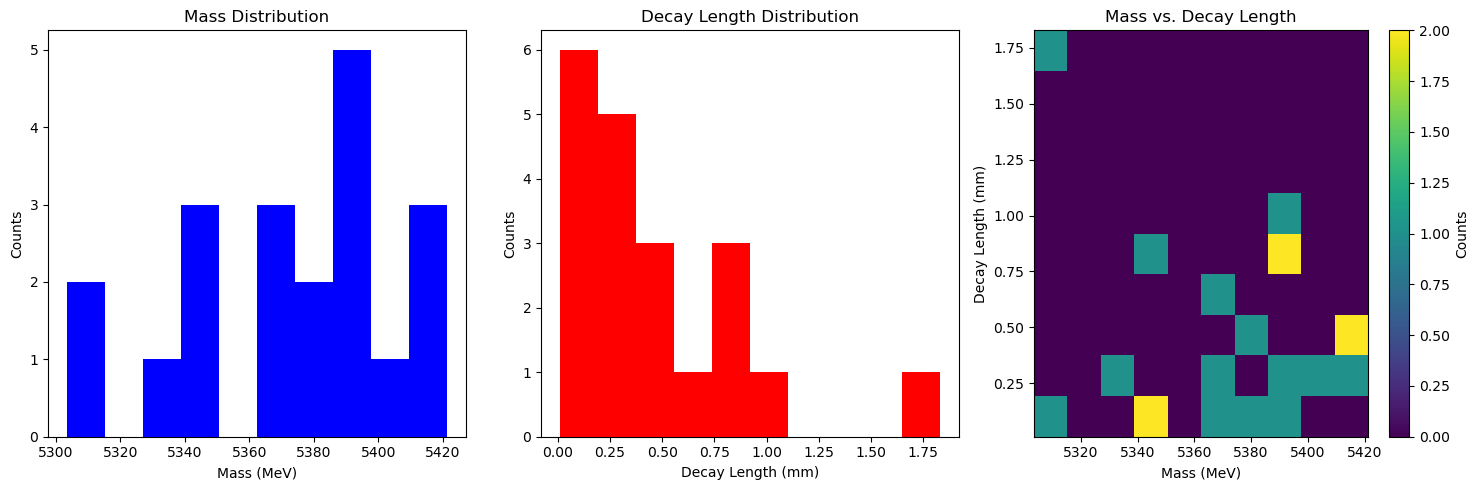

In [80]:
# plot 1D projections and 2D histograms
# since we assume that mass and decay time are uncorrelated
# this boils down to plotting mass and decay time separately
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(data.mass, color='b')
axes[0].set_xlabel("Mass (MeV)")
axes[0].set_ylabel("Counts")
axes[0].set_title("Mass Distribution")

axes[1].hist(data.decay_length, color='r')
axes[1].set_xlabel("Decay Length (mm)")
axes[1].set_ylabel("Counts")
axes[1].set_title("Decay Length Distribution")

h = axes[2].hist2d(data.mass, data.decay_length)
axes[2].set_xlabel("Mass (MeV)")
axes[2].set_ylabel("Decay Length (mm)")
axes[2].set_title("Mass vs. Decay Length")
fig.colorbar(h[3], ax=axes[2], label="Counts")

plt.tight_layout()
plt.show()

there's definitely not many events, let's compute the estimator for the mean of both mass and decay length

In [81]:
print(f"{'Mass Mean:':} {np.mean(data.mass)}")
print(f"{'Mass Variance:':} {np.std(data.mass)}")
print(f"{'Decay length Mean:':} {np.mean(data.decay_length)}")

Mass Mean: 5374.003524350001
Mass Variance: 32.95023020018367
Decay length Mean: 0.48104335000000004


let's define three functions that we'll use for the fit, assuming that the mass is distributed normally, the decay length follows an exponential decay PDF and the combined PDF is just the product of the two, given they are not correlated.  

**Do not forget the normalization factors in the PDFs**

In [82]:
def gaussian(x, mu, sigma):
    return 1. / (sigma * np.sqrt(2 * np.pi)) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

def exponential(x, ctau):
    return 1. / ctau * np.exp(-x/ctau)

def composite_pdf(x, mu, sigma, ctau):
    return gaussian(x[:,0], mu, sigma) * exponential(x[:,1], ctau)

also create the Likelihood and Negative LogLikelihood classes (`dataclass` is not strictly needed, but makes the class definition neater, check the [docs](https://docs.python.org/3/library/dataclasses.html))

In [83]:
@dataclass
class Likelihood:
    function: callable
    data: np.ndarray

    def __call__(self, *params):
        return np.prod(self.function(self.data, *params))

  
class NLL(Likelihood):
    def __call__(self, *params):
        return -np.sum([np.log(self.function(self.data, *params))])

Let's now run the 1D and 2D scans and find the best-fit values.  

Let's also fetch the $\mathrm{B}_{\mathrm{s}}$ meson mass and lifetime (heavy eigenstate) from the PDG.  
```
mass = mu = 5366.3 # Bs meson mass in MeV
sigma = 30. # CMS resolution in MeV 
# ctau ==> decay length = lifetime * sped of light
# Bs meson lifetime for the heavy eigenstate (1.622 picosec)
# times speed of light in millimeters/sec (notice factor 1000.)
ctau = 1.622e-12 * speed_of_light * 1000. 
```

NLL scan of the mass projection (gaussian)

In [85]:
mass = mu = 5366.3 # Bs meson mass in MeV
sigma = 30. # CMS resolution in MeV 
# ctau ==> decay length = lifetime * sped of light
# Bs meson lifetime for the heavy eigenstate (1.622 picosec)
# times speed of light in millimeters/sec (notice factor 1000.)
ctau = 1.622e-12 * speed_of_light * 1000. 

lkl = Likelihood(gaussian, data.mass)
nll = NLL(gaussian, data.mass)

mass_range = np.linspace(5300, 5450, 100)  # 100 points
nll_scan_mass = np.array([nll(imass, sigma) for imass in mass_range]) # at fixed sigma
nll_scan_mass -= np.min(nll_scan_mass) # fix the 0 to the NLL minimum

NLL scan of the decay length projection (falling exponential)

In [86]:
lkl = Likelihood(exponential, data.decay_length)
nll = NLL(exponential, data.decay_length)

decay_length_range = np.linspace(0.2, 1., 100)   # 100 points
nll_scan_ctau = np.array([nll(ictau) for ictau in decay_length_range])
nll_scan_ctau -= np.min(nll_scan_ctau) # fix the 0 to the NLL minimum

2D NLL scan of mass x decay length

In [87]:
lkl = Likelihood(composite_pdf, data.to_numpy()) # it wants numpy arrays, not pandas
nll = NLL(composite_pdf, data.to_numpy()) # it wants numpy arrays, not pandas

# Create meshgrid for plotting gradient
M, D = np.meshgrid(mass_range, decay_length_range)

# scan at fixed sigma
nll_scan_2d = np.array([[nll(imass, sigma, ictau) for imass in mass_range] for ictau in decay_length_range])

# NLL minimum
min_nll_2d = np.min(nll_scan_2d)
delta_nll_scan_2d = nll_scan_2d - min_nll_2d

now plot the 1D and the 2D scans

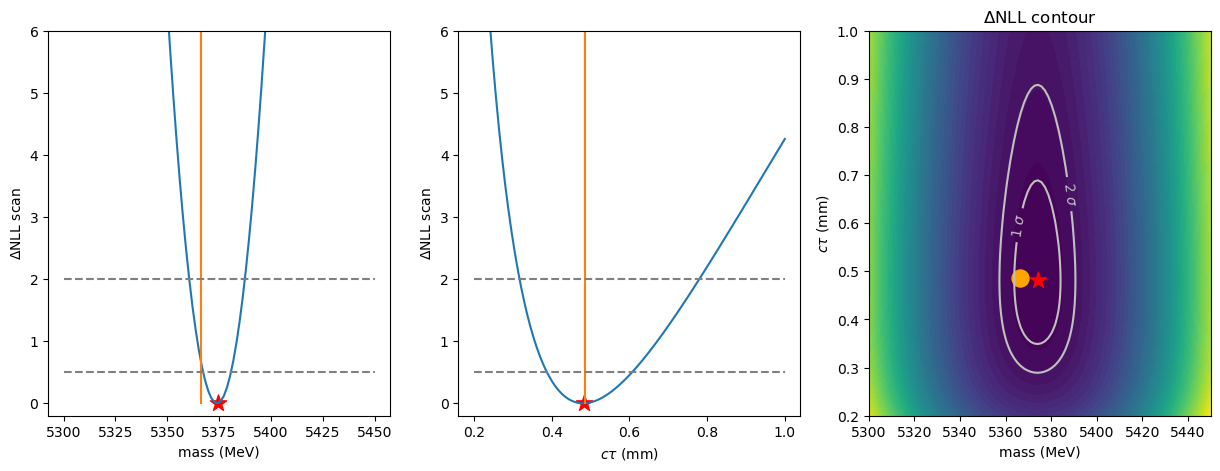

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(mass_range, nll_scan_mass)
axes[0].plot([mu, mu],[0., np.max(nll_scan_mass)]) # plot truth
axes[0].plot([np.min(mass_range), np.max(mass_range)],[0.5, 0.5], color='gray', linestyle='--')  # 1 sigma
axes[0].plot([np.min(mass_range), np.max(mass_range)],[2. , 2. ], color='gray', linestyle='--')  # 2 sigma
axes[0].scatter(mass_range[np.argmin(nll_scan_mass)], 0., color='red', marker='*', s=150) # plot best fit mass
axes[0].set_xlabel("mass (MeV)")
axes[0].set_ylabel("$\Delta$NLL scan")
axes[0].set_ylim(-0.2, 6.)

axes[1].plot(decay_length_range, nll_scan_ctau)
axes[1].plot([ctau, ctau],[0., np.max(nll_scan_ctau)]) # plot truth
axes[1].plot([np.min(decay_length_range), np.max(decay_length_range)],[0.5, 0.5], color='gray', linestyle='--')  # 1 sigma
axes[1].plot([np.min(decay_length_range), np.max(decay_length_range)],[2. , 2. ], color='gray', linestyle='--')  # 2 sigma
axes[1].scatter(decay_length_range[np.argmin(nll_scan_ctau)], 0., color='red', marker='*', s=150) # plot best fit decay length
axes[1].set_xlabel(r"$c\tau$ (mm)")
axes[1].set_ylabel("$\Delta$NLL scan")
axes[1].set_ylim(-0.2, 6.)

contour = axes[2].contourf(M, D, delta_nll_scan_2d, levels=50, cmap='viridis')
#levels = [0.5, 2.]
levels = [1.15, 3.09]
levels_str = [r'1 $\sigma$', r'2 $\sigma$']
isometrics = axes[2].contour(M, D, delta_nll_scan_2d, levels=levels, colors='silver')
fmt = {}
for l, s in zip(isometrics.levels, levels_str):
    fmt[l] = s
axes[2].clabel(isometrics, isometrics.levels, inline=True, fmt=fmt)

axes[2].set_xlabel("mass (MeV)")
axes[2].set_ylabel(r"$c\tau$ (mm)")
axes[2].set_title("$\Delta$NLL contour")
axes[2].scatter(mass_range[np.argmin(nll_scan_mass)], decay_length_range[np.argmin(nll_scan_ctau)], color='red', marker='*', s=150, label='best estimate')
axes[2].scatter(mu, ctau, color='orange', marker='o', s=150, label='truth')

plt.show()

print the best fit parameteres

In [89]:
best_fit_mass = mass_range[np.argmin(nll_scan_mass)]
best_fit_decay_length = decay_length_range[np.argmin(nll_scan_ctau)]
print(f"{'best-fit Bs mass:':} {best_fit_mass:.2f}", "MeV")
print(f"{'best-fit Bs decay length:':} {best_fit_decay_length:.4f}", "mm")

best-fit Bs mass: 5374.24 MeV
best-fit Bs decay length: 0.4828 mm


### minimize using minimizer

we'll use `scipy.optimize.minimize`.  
It requires the parameters to be passed as an array, rather than one by one as we've done above.  
We therefore need to write a "wrapper" function, where, incidentally, we fix sigma too.

In [90]:
from scipy.optimize import minimize

def nll_wrapper(params):
    mu, _, ctau = params  # unpack parameters
    sigma = 30. # sigma is fixed
    return nll(mu, sigma, ctau)

# initial parameters (mu, sigma, ctau)
initial_guess = [5350, 30, 0.4]  

# minimization
result = minimize(nll_wrapper, initial_guess)

print("Optimized Mu:", result.x[0])
print("Optimized cτ:", result.x[2])
print("Minimum NLL:", result.fun)

Optimized Mu: 5374.003515847058
Optimized cτ: 0.48104334606533794
Minimum NLL: 103.83029020278248


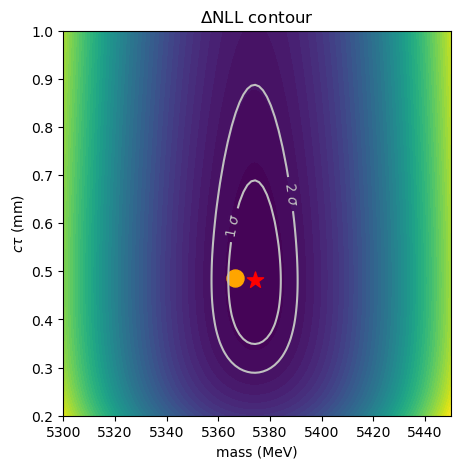

In [91]:
# Compute NLL values over the grid
nll_values = np.array([[nll_wrapper([imass, sigma, ictau]) for imass in mass_range] for ictau in decay_length_range])

min_nll = np.min(nll_values)
delta_nll = nll_values - min_nll  # ΔNLL

# plot
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

contour = axes.contourf(M, D, delta_nll, levels=50, cmap='viridis')
#levels = [0.5, 2.]
levels = [1.15, 3.09]
levels_str = [r'1 $\sigma$', r'2 $\sigma$']
isometrics = axes.contour(M, D, delta_nll_scan_2d, levels=levels, colors='silver')
fmt = {}
for l, s in zip(isometrics.levels, levels_str):
    fmt[l] = s
axes.clabel(isometrics, isometrics.levels, inline=True, fmt=fmt)
axes.set_xlabel("mass (MeV)")
axes.set_ylabel(r"$c\tau$ (mm)")
axes.set_title("$\Delta$NLL contour")
axes.scatter(mass_range[np.argmin(nll_scan_mass)], decay_length_range[np.argmin(nll_scan_ctau)], color='red', marker='*', s=150, label='best estimate')
axes.scatter(mu, ctau, color='orange', marker='o', s=150, label='truth')

plt.show()


### 3) Extended PDF

Before moving to a more realistic example (next exercise), let's implement an _extended_ ML fit to a simple normally distributed dataset.
That is, not only we want to estimate the mean and width of the normal distribution, we also want to estimate the yield.

1. generate 1000 normally distributed events, with $\mu=0$ and $\sigma=1$
2. write the extended NLL (hint: remember we want to _minimize_ the ENLL, are all terms needed?)
3. fit using `scipy.optimize.minimize` to estimate $N$, $\mu$, $\sigma$, where $N$ is the number of events
    1. be careful with initial parameters (don't pass it the exact parameters you used for generation, but don't give it nonsense numbers either)
    2. notice that $\sigma$ cannot be negative ==> you need to impose bounds 
5. estimate the uncertainties from the covariance matrix (hint: remember how it is related to the hessian)
    1. what uncertainty do you expect for $N$?

### solution

imports and generate the dataset

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import speed_of_light
from dataclasses import dataclass
import pandas as pd
from scipy.stats import poisson, norm
from scipy.optimize import minimize, curve_fit
import seaborn as sns

# fix seed
np.random.seed(1986)

# Generate toy data
data = np.random.normal(0, 1., 1000)

write the extended likelihood and negative log likelihood classes.  
When taking the log of the poissonian term that multiplies the likelihood, the constant term $\log(len(data)!)$ can (and should!) be neglected

In [93]:
@dataclass
class ExtendedNLL:
    function: callable
    data: np.ndarray

    def __call__(self, params):

        N = params[0] # number of events
    
        log_likelihood   = np.sum([np.log(self.function(self.data, params[1:]))])
        # we neglect the factorial constant, irrelevant for minimization
        log_poisson_term = -N + len(self.data)*np.log(N) # - np.log(np.math.factorial(len(self.data)))
    
        return - (log_likelihood + log_poisson_term)

Now write the gaussian pdf

In [94]:
def gaussian(x, params):
    mu, sigma = params
    likelihood = 1. / (sigma * np.sqrt(2 * np.pi)) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))
    return likelihood

you have now all the ingredients, instantiate an `ExtendedNLL` object on your dataset and minimize it

In [95]:
nll = ExtendedNLL(gaussian, data)

# N, mean, sigma
initial_guess = [200, 0.1, 0.8]

# N, mean, sigma
bounds = [
    (1, 1e6),
    (-1., 1.),
    (1e-3, 100.),
]

result = minimize(nll, initial_guess, options={'disp':True}, bounds=bounds)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -3.59144D+03    |proj g|=  9.92000D+01

At iterate    1    f= -3.62346D+03    |proj g|=  3.99950D+00

At iterate    2    f= -3.65356D+03    |proj g|=  3.99959D+00

At iterate    3    f= -3.66606D+03    |proj g|=  3.99959D+00

At iterate    4    f= -3.66699D+03    |proj g|=  2.27235D+01

At iterate    5    f= -3.66712D+03    |proj g|=  3.99950D+00

At iterate    6    f= -3.66713D+03    |proj g|=  3.99950D+00

At iterate    7    f= -3.66721D+03    |proj g|=  3.99886D+00

At iterate    8    f= -3.66733D+03    |proj g|=  3.99750D+00

At iterate    9    f= -3.66774D+03    |proj g|=  3.99341D+00

At iterate   10    f= -3.66872D+03    |proj g|=  3.98204D+00

At iterate   11    f= -3.67133D+03    |proj g|=  3.95130D+00

At iterate   12    f= -3.67792D+03    |proj g|=  3.87335D+00

At iterate   13    f= -3.6

We evaluate the hessian at the NLL minimum (and then invert it) using numerical differentiation packages, such as `autograd`. Other options, e.g. `jax`

In [96]:
from autograd import hessian
import autograd.numpy as np

hess = hessian(nll)
H = hess(result.x)
covariance = np.linalg.pinv(H) # "pseudo" inversion, rule of thumb: always use this unless you're 100% sure the matrix is well behaved, non singular and the eigenvavlues are all of the same magnitude. 
uncertainties = np.sqrt(np.diag(covariance))
correlation = covariance / np.outer(uncertainties, uncertainties)

Success:             True
Status:              0
Best-fit yield:      999.9794 +/- 31.6221
Best-fit mu:         -0.0149 +/- 0.0320
Best-fit sigma:      1.0124 +/- 0.0226
Minimum NLL:         -4476.4795
Covariance:          
[[ 9.99958899e+02  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.02499184e-03 -3.47336359e-09]
 [ 0.00000000e+00 -3.47336359e-09  5.12503768e-04]]


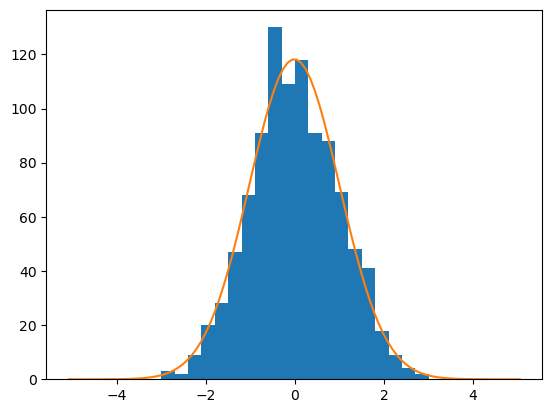

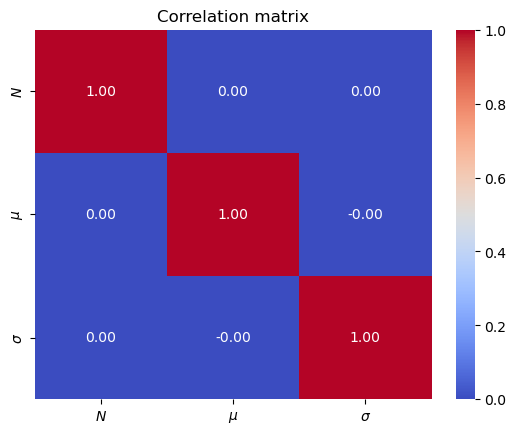

In [97]:
# Print results
print(f"{'Success:':<20} {result.success}")
print(f"{'Status:':<20} {result.status}")
print(f"{'Best-fit yield:':<20} {result.x[0]:.4f} +/- {uncertainties[0]:.4f}")
print(f"{'Best-fit mu:':<20} {result.x[1]:.4f} +/- {uncertainties[1]:.4f}")
print(f"{'Best-fit sigma:':<20} {result.x[2]:.4f} +/- {uncertainties[2]:.4f}")
print(f"{'Minimum NLL:':<20} {result.fun:.4f}")
print(f"{'Covariance:':<20} \n{covariance}")

# plot distribution and fitted curve
bins = np.linspace(-3, 3, 21)
bin_width = (np.max(bins) - np.min(bins)) / (len(bins)-1)

# Overlay the theoretical Gaussian distribution
x = np.linspace(result.x[1] - 5*result.x[2], result.x[1] + 5*result.x[2], 100)
y = result.x[0] * bin_width * norm.pdf(x, result.x[1], result.x[2])

plt.hist(data, bins=bins)#, density=True)
plt.plot(x, y)
plt.show()

# plot correlation matrix
labels = [r'$N$', r'$\mu$', r'$\sigma$']
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, xticklabels=labels, yticklabels=labels)
plt.title("Correlation matrix")

plt.show()

Since $N$ is poisson distributed, we expect the fit to return an uncertainty of $\sqrt{N}$, and it does $\sqrt{1000} = 31.62$.  
Also, $N$ is not correlated with the other two parameters, whereas $\mu$ and $\sigma$ are only very, very mildly correlated.

## 4) Realistic case, extended fit, signal and background  

In this exercise you'll experiment with a realistic example similar to the simpler one discussed in exercise 2.  

The dataset `data.csv` contains the values of mass and decay length for signal which can be either signal or background.

1. load the dataset and plot 1D and 2D distributions
2. perform an extended max-likelihood fit to the 2D distribution mass x decay length
    1. the proportion between signal and background is unknown, but the total S + B yield must correspond to the number of events
    2. from the plotted distributions, make an educated guess on which PDFs to use for signal and background
    3. be careful with parameter bounds and initial guesses. This fit is more finicky than before...
    4. what's more, you might have to play with the minimizer's parameters, such that tolerance and gradient step size
    5. if the parameters have very different scales, this can create numerical instabilities (hint: to help convergencency, you might have to scale some parameters)
3. redo the 1D and 2D plots, overlay the fitted S+B function as well as the S and B components separately
4. estimate the uncertainties
5. "corner plot": plot all pairwise 2D NLL scans as well as the 1D marginal scans. Discuss whether any variables are correlated and try to explain why that happens by relating our observations to the characteristics of the 1D and 2D plots

#### solution

Success:             True
Status:              0
Best-fit yield:      110007.6283 +/- 331.6855
Best-fit B mass:     5.3660 +/- 0.0004
Best-fit resolution: 0.0295 +/- 0.0003
Best-fit B ctau:     0.4840 +/- 0.0053
Best-fit bkg mass slope: 2.0004 +/- 0.0064
Best-fit bkg ctau:   0.1461 +/- 0.0005
Best-fit fsig:       0.0905 +/- 0.0011
Minimum NLL:         -1081940.2329
Covariance:          
[0.00331685 0.0003773  0.00030848 0.00529706 0.00636855 0.00047141
 0.00105053]
Minimum NLL: -1081940.232933473


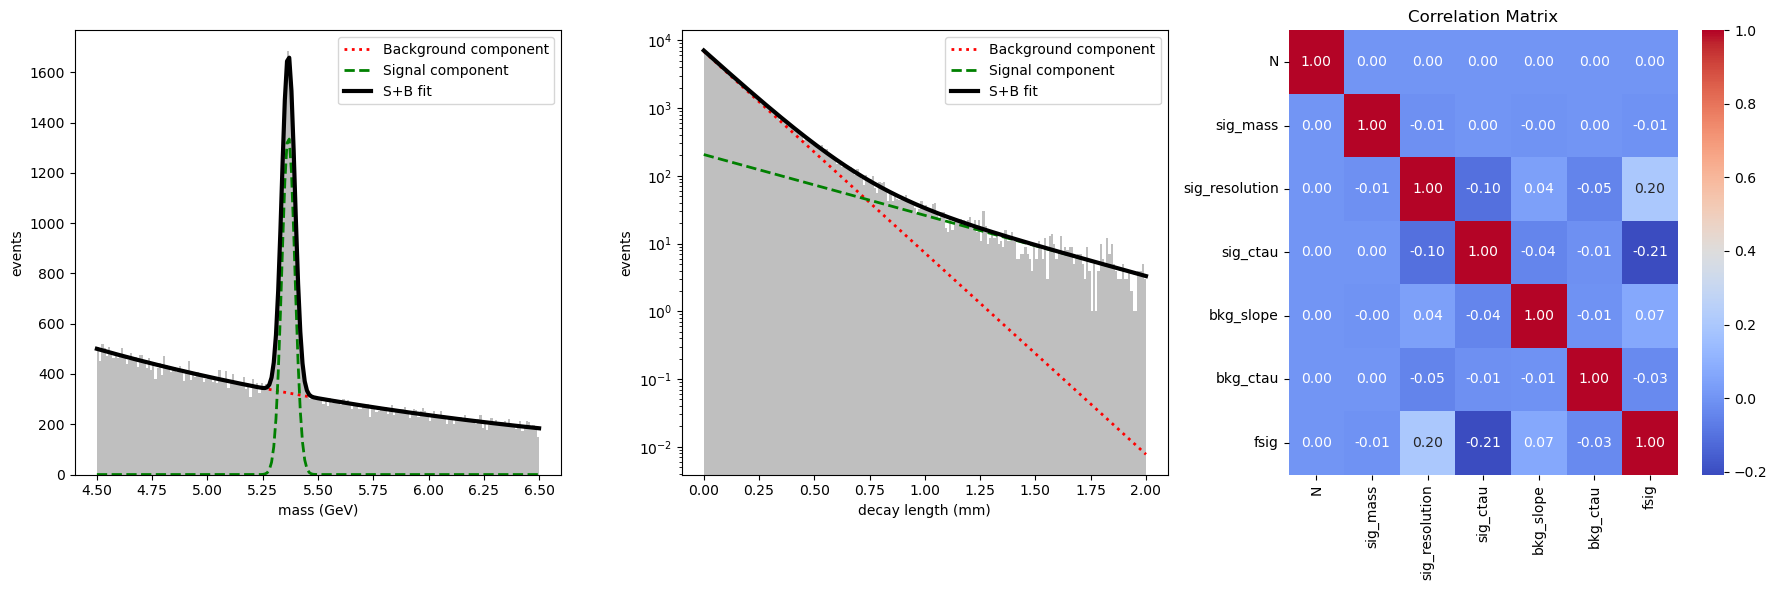

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import speed_of_light
from scipy.stats import poisson, norm, expon
from scipy.optimize import minimize, approx_fprime, curve_fit
from dataclasses import dataclass
import seaborn as sns
import pandas as pd

verbose = False
debug = False

# fix seed
np.random.seed(1986)

# Number of events
yield_scale = 1e5

data = pd.read_csv("data.csv")

@dataclass
class ExtendedNLL:

    function: callable
    data: np.ndarray

    def __call__(self, params):

        N = params[0] * yield_scale
    
        log_likelihood   = np.sum(np.log(self.function(self.data, params[1:])))
        # remove the constant factorial term, irrelevant for minimization
        log_poisson_term = -N + len(self.data)*np.log(N) # - np.log(np.math.factorial(len(self.data)))

        nll = -(log_likelihood + log_poisson_term)

        if verbose: print(f"pars: {params}")
        if verbose: print(f"Log-Likelihood: {log_likelihood:.6f}, Poisson: {log_poisson_term:.6f}, NLL:{nll:.6f}")

        if log_likelihood == -np.inf or np.isnan(log_likelihood):
             if debug: import ipdb ; ipdb.set_trace()
             log_likelihood = np.nan_to_num(log_likelihood)
             
        return nll

##########################################################################################
##########################################################################################

def gaussian(x, params):
    mu, sigma = params
    return 1. / (sigma * np.sqrt(2 * np.pi)) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# starts from zero, for lifetime
def exponential(x, params):
    ctau, = params
#     print(f"{ctau}, {np.max(-x/ctau), np.min(-x/ctau)}")
    return 1. / ctau * np.exp(-x/ctau)

# starts from fixed_offset, for background mass pdf
fixed_offset = 4.5
def exponential_with_offset(x, params):
    ctau, = params
    return 1. / ctau * np.exp(-(x-fixed_offset)/ctau)

def signal_pdf(x, params):
    mu, sigma, ctau = params
    return gaussian(x[:,0], [mu, sigma]) * exponential(x[:,1], [ctau])

def bkg_pdf(x, params):
    slope, ctau = params
    return exponential_with_offset(x[:,0], [slope]) * exponential(x[:,1], [ctau])

def total_pdf(x, params):
    mu, sigma, ctau, bkg_slope, bkg_ctau, fsig = params
    signal = signal_pdf(x, [mu, sigma, ctau]    )
    bkg    = bkg_pdf   (x, [bkg_slope, bkg_ctau])
    total_pdf = fsig * signal + (1.-fsig) * bkg # fsig is the fraction of signal, formalized this way, fbkg = 1 - fsig, sich that the two fraction add up to 1.
    return total_pdf

##########################################################################################
##########################################################################################

# initial reasonable (hopefully?) guesses
initial_guess = dict()
initial_guess['N'             ] = 2      
initial_guess['sig_mass'      ] = 5.350  
initial_guess['sig_resolution'] = 0.035  
initial_guess['sig_ctau'      ] = 0.6    
initial_guess['bkg_slope'     ] = 1.5    
initial_guess['bkg_ctau'      ] = 0.1    
initial_guess['fsig'          ] = 0.5    

# reasonable (hopefully?) boundaries
bounds = dict()
bounds['N'             ] = ( 0.5, 7   )
bounds['sig_mass'      ] = ( 5.3 ,  5.4 )
bounds['sig_resolution'] = ( 0.01,  0.1 )
bounds['sig_ctau'      ] = ( 1e-2, 10   )
bounds['bkg_slope'     ] = ( 0.5 , 10   )
bounds['bkg_ctau'      ] = ( 1e-2, 10   )
bounds['fsig'          ] = ( 0.01,  0.99   )

# define likelihood and negative log likelihood
nll = ExtendedNLL       (total_pdf, data.to_numpy())

# choose epsilon as the square root of the machine precision
eps = np.sqrt(np.finfo(float).eps)

options = {
    "disp": True,      
    "maxiter": 10000,  # more iterations, if needed for convergence
    "gtol": 1e-9,      # gradient tolerance
    "eps": eps,        # gradient evaluation step size, match it to machine precision
    "ftol": 1e-12,     # function tolerance, small distance to minimum
}

# NLL minimization
# for more info on the method chosen, L-BFGS-B 
# see https://docs.scipy.org/doc/scipy/tutorial/optimize.html#local-minimization-of-multivariate-scalar-functions-minimize
# try also with other methods, some don't even use gradient descent, eg. Nelder-Mead
result = minimize(nll, list(initial_guess.values()), bounds=list(bounds.values()), method='L-BFGS-B')

# check minimize's hess_inv --> it does not work well for this realistic case, uncertainties are wrong
# resort to numerical differenciation libraries (e.g. autograd or jax) to evaluate the Hessian at the best-fit point
# then covariance =  H-1
from autograd import hessian
import autograd.numpy as np

hess = hessian(nll)
H = hess(result.x)
covariance = np.linalg.pinv(H)
uncertainties = np.sqrt(np.diag(covariance))
correlation = covariance / np.outer(uncertainties, uncertainties)
#################################################################
   
# Print results
print(f"{'Success:':<20} {result.success}")
print(f"{'Status:':<20} {result.status}")
print(f"{'Best-fit yield:':<20} {result.x[0]*yield_scale:.4f} +/- {uncertainties[0]*yield_scale:.4f}") # notice that this converges to the number of data entries, as it should, and it's uncertainty is poissonina, as it should be, sqrt(Nevents)
print(f"{'Best-fit B mass:':<20} {result.x[1]:.4f} +/- {uncertainties[1]:.4f}")
print(f"{'Best-fit resolution:':<20} {result.x[2]:.4f} +/- {uncertainties[2]:.4f}")
print(f"{'Best-fit B ctau:':<20} {result.x[3]:.4f} +/- {uncertainties[3]:.4f}")
print(f"{'Best-fit bkg mass slope:':<20} {result.x[4]:.4f} +/- {uncertainties[4]:.4f}")
print(f"{'Best-fit bkg ctau:':<20} {result.x[5]:.4f} +/- {uncertainties[5]:.4f}")
print(f"{'Best-fit fsig:':<20} {result.x[6]:.4f} +/- {uncertainties[6]:.4f}")
print(f"{'Minimum NLL:':<20} {result.fun:.4f}")
print(f"{'Covariance:':<20} \n{uncertainties}")
print("Minimum NLL:", result.fun)

# plot fit and data 1D projections, plus the parameter correlation matrix from the fit
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bins = np.linspace(4.5, 6.5, 201)
bin_width = (np.max(bins) - np.min(bins)) / (len(bins)-1)

normalization = yield_scale * bin_width * result.x[0]

x = np.linspace(np.min(bins), np.max(bins), len(bins))
y_sig = result.x[6]        * (normalization * norm.pdf(x, result.x[1], result.x[2]))
y_bkg = (1. - result.x[6]) * (normalization * expon.pdf(x, loc=4.5, scale=result.x[4]) )
y = y_sig + y_bkg

axes[0].hist(data.mass, bins=bins, alpha=0.5, color='gray')
axes[0].plot(x, y_bkg, 'r:'   , linewidth=2.0, label="Background component")
axes[0].plot(x, y_sig, 'g--'  , linewidth=2.0, label="Signal component"    )
axes[0].plot(x, y    , 'black', linewidth=3.0, label="S+B fit"             )
axes[0].set_title("")
axes[0].set_xlabel("mass (GeV)")
axes[0].set_ylabel("events")
axes[0].legend()

bins = np.linspace(0, 2, 201)
bin_width = (np.max(bins) - np.min(bins)) / (len(bins)-1)

normalization = yield_scale * bin_width * result.x[0]

x = np.linspace(np.min(bins), np.max(bins), len(bins))
y_sig = result.x[6]        * (normalization * expon.pdf(x, loc=0., scale=result.x[3]) )
y_bkg = (1. - result.x[6]) * (normalization * expon.pdf(x, loc=0., scale=result.x[5]) )
y = y_sig + y_bkg

axes[1].hist(data.decay_length, bins=bins, alpha=0.5, color='gray')
axes[1].plot(x, y_bkg, 'r:'   , linewidth=2.0, label="Background component")
axes[1].plot(x, y_sig, 'g--'  , linewidth=2.0, label="Signal component"    )
axes[1].plot(x, y    , 'black', linewidth=3.0, label="S+B fit"             )
axes[1].set_yscale("log")
axes[1].set_title("")
axes[1].set_xlabel("decay length (mm)")
axes[1].set_ylabel("events")
axes[1].legend()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", cbar=True,
            xticklabels=initial_guess.keys(), yticklabels=initial_guess.keys())

axes[2].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()


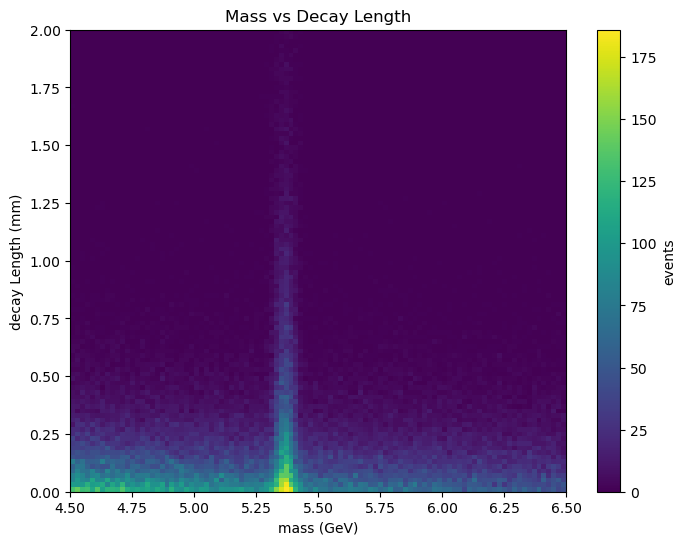

In [99]:
plt.figure(figsize=(8, 6))
plt.hist2d(data.mass, data.decay_length, bins=[100, 100],range=[[4.5, 6.5], [0, 2]])
plt.colorbar(label="events")
plt.xlabel("mass (GeV)")
plt.ylabel("decay Length (mm)")
plt.title("Mass vs Decay Length")
plt.show()

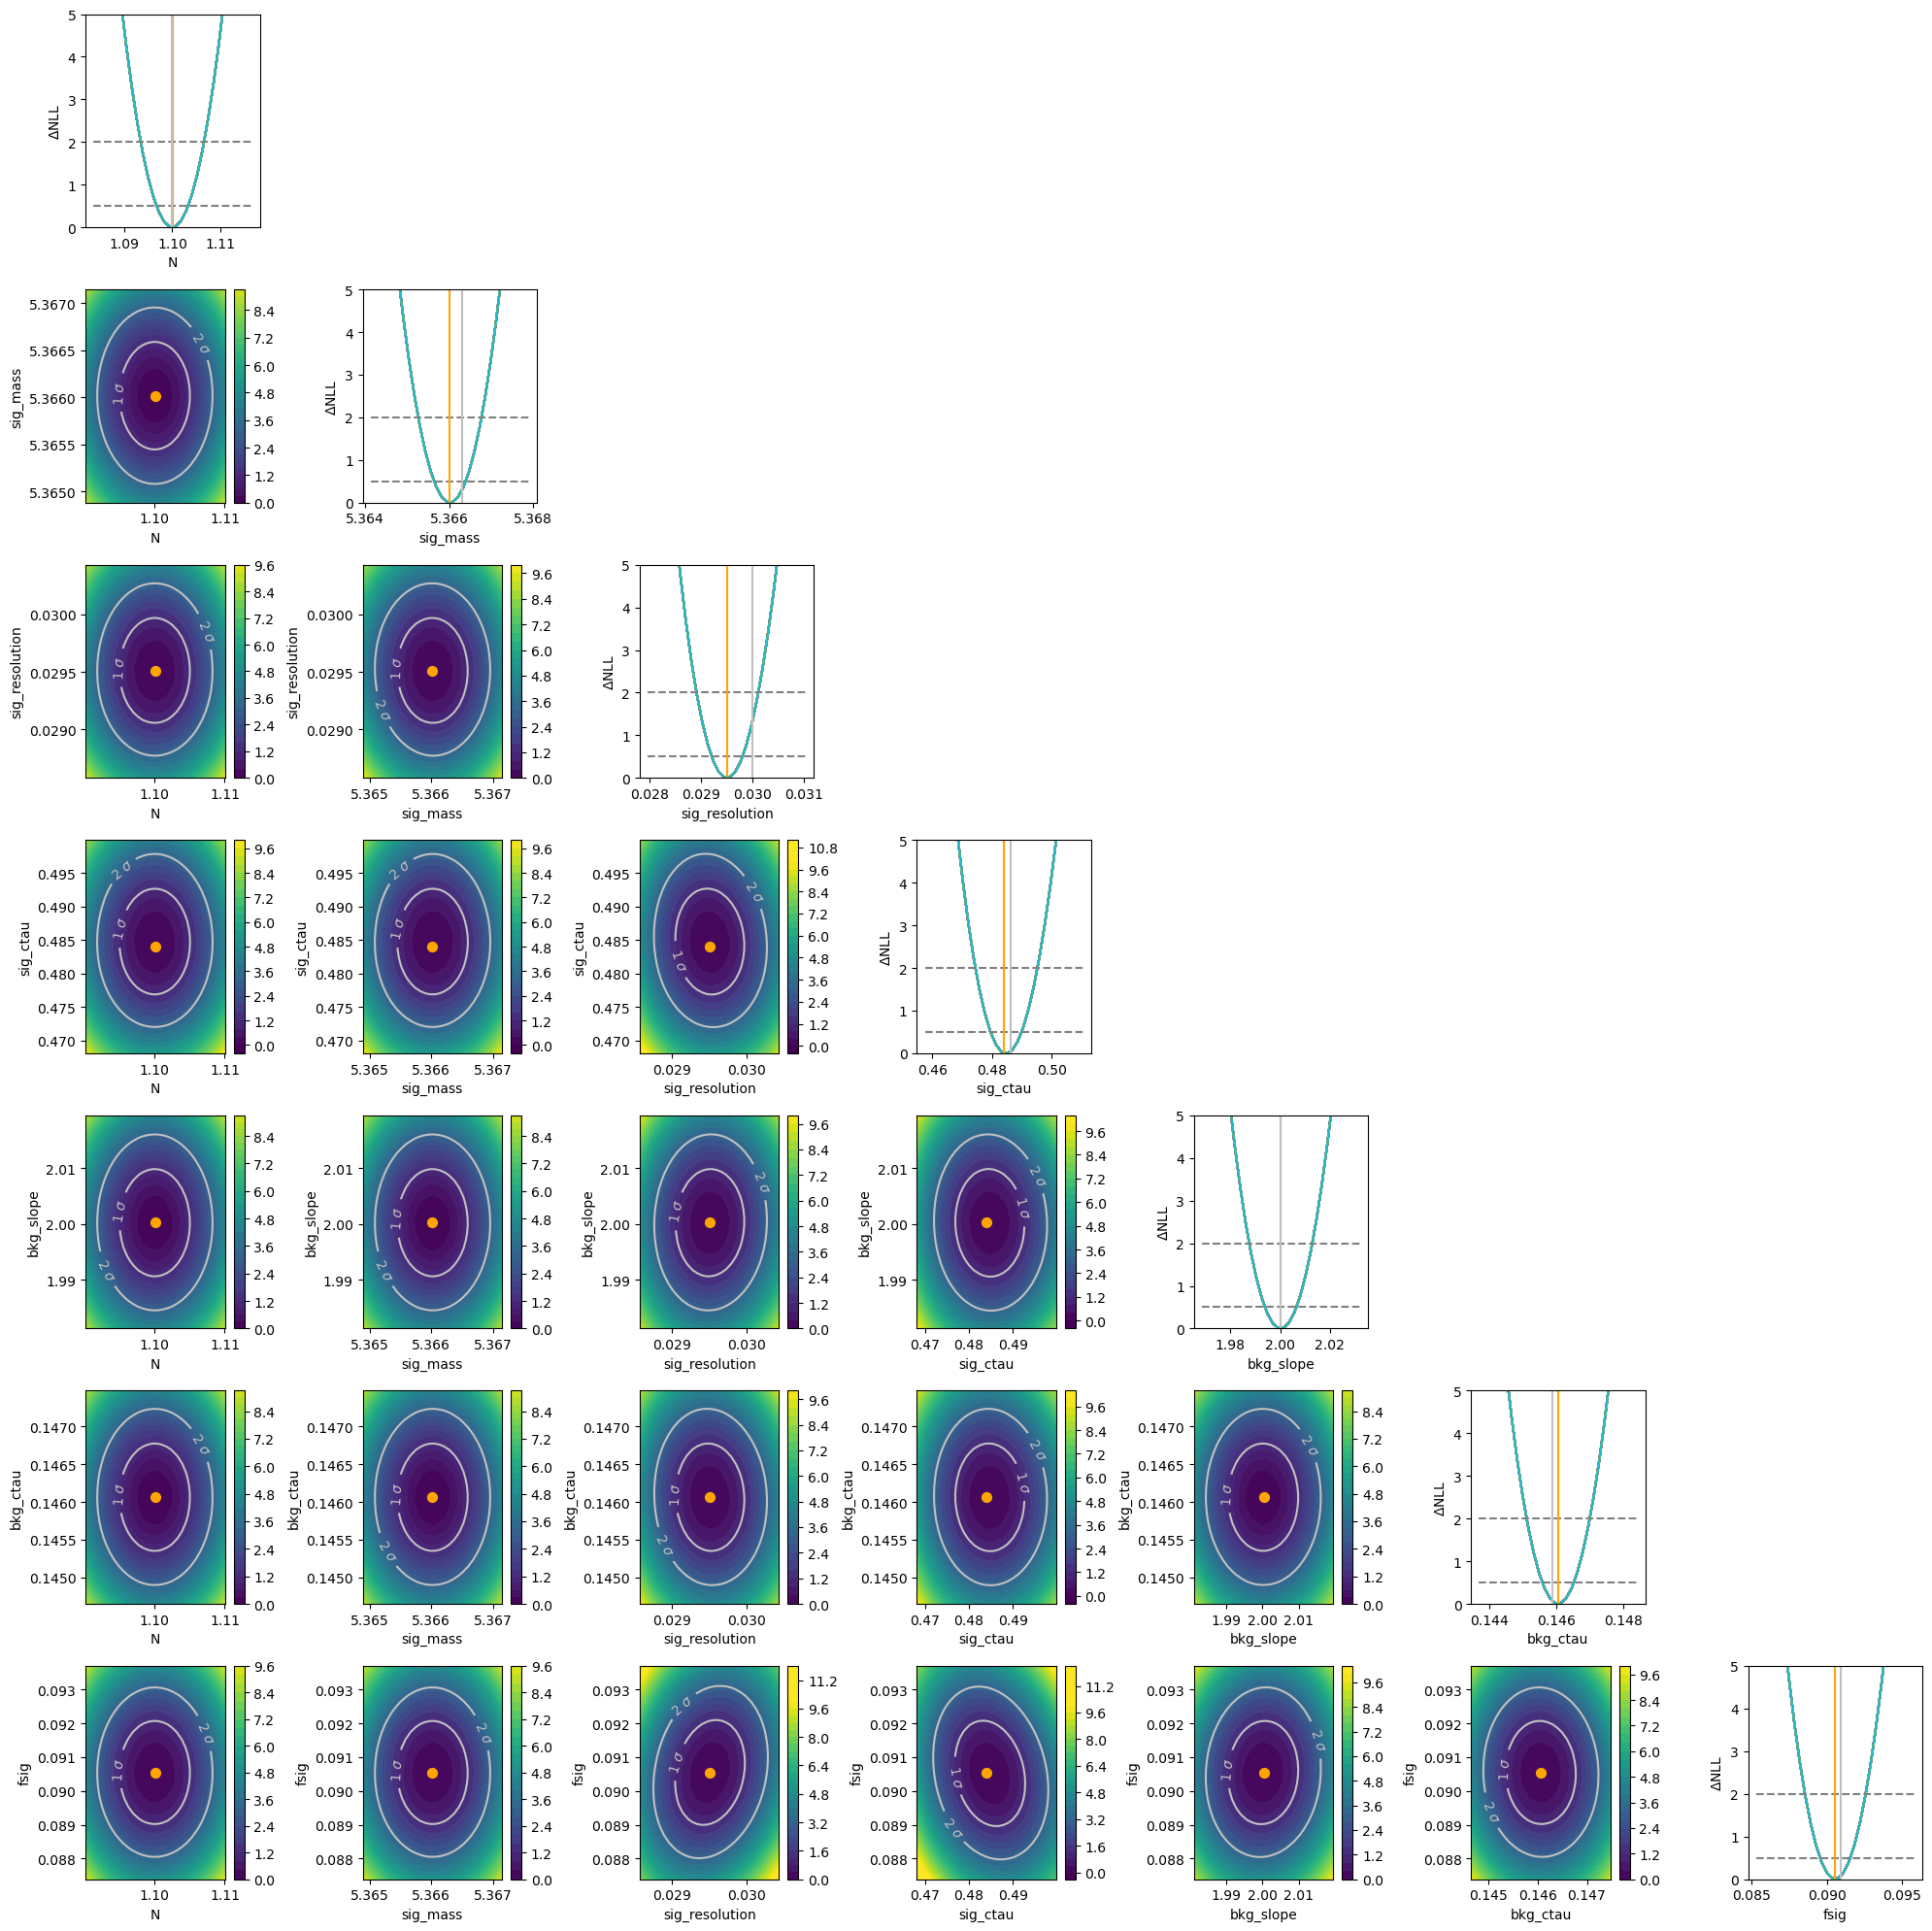

In [101]:
import itertools

# Extract best-fit parameters
Nsig = 10000 # God's truth, this is what I generated
Nbkg = 100000 # God's truth, this is what I generated
true_params = [(Nsig+Nbkg)/yield_scale, mu/1000., sigma/1000., ctau, 2, 0.3*ctau, Nsig/(Nsig+Nbkg)]
best_fit_params = result.x
param_names = list(initial_guess.keys())

# Define number of steps for scanning each parameter pair
num_steps = 30

fig, axes = plt.subplots(len(best_fit_params), len(best_fit_params), figsize=(20, 20))

for i, j in itertools.combinations(range(len(param_names)), 2):
    param1, param2 = param_names[i], param_names[j]
    
    # Parameter value grids, nsigmas sigma either way
    nsigmas = 3
    p1_vals = np.linspace(best_fit_params[i] - nsigmas * uncertainties[i], best_fit_params[i] + nsigmas * uncertainties[i], num_steps)
    p2_vals = np.linspace(best_fit_params[j] - nsigmas * uncertainties[j], best_fit_params[j] + nsigmas * uncertainties[j], num_steps)
    
    # Store NLL values
    nll_values = np.zeros((num_steps, num_steps))
    
    # Loop over grid points and evaluate NLL
    for i1, p1 in enumerate(p1_vals):
        for i2, p2 in enumerate(p2_vals):
            test_params = best_fit_params.copy()
            test_params[i] = p1
            test_params[j] = p2
            nll_values[i1, i2] = nll(test_params)
    
    # Convert NLL to delta-NLL (relative to minimum)
    nll_values -= result.fun
    
    # Plot the contour
    ax = axes[j, i]
    
    c = ax.contourf(p1_vals, p2_vals, nll_values.T, levels=30, vmin=0, vmax=10)
    plt.colorbar(c, ax=ax)

    # plot best fit point
    ax.scatter(best_fit_params[i], best_fit_params[j], color='orange', marker='.', s=200)
    
    # plot true parameter
    #ax.scatter(true_params[i], true_params[j], color='silver', marker='*', s=200)

    levels = [1.15, 3.09]
    levels_str = [r'1 $\sigma$', r'2 $\sigma$']
    isometrics = ax.contour(p1_vals, p2_vals, nll_values.T, levels=levels, colors='silver')
    fmt = {}
    for l, s in zip(isometrics.levels, levels_str):
        fmt[l] = s
    ax.clabel(isometrics, isometrics.levels, inline=True, fmt=fmt)

    ax.set_xlabel(param1)
    ax.set_ylabel(param2)
    
    #if i==0: ax.set_xlabel(param1)
    #if j==0: ax.set_ylabel(param2)

for i, j in itertools.product(range(len(best_fit_params)), range(len(best_fit_params))):
    if j>i:
        axes[i,j].axis('off')
    if i!=j: continue

    ax = axes[i,i]
    
    param1 = param_names[i]
    
    # Parameter value grids, 3 sigma either way
    nsigmas = 5
    p1_vals = np.linspace(result.x[i] - nsigmas * uncertainties[i], result.x[i] + nsigmas * uncertainties[i], num_steps)

    # Store NLL values
    nll_values = np.zeros((num_steps, num_steps))
    
    # Loop over grid points and evaluate NLL
    for i1, p1 in enumerate(p1_vals):
        test_params = best_fit_params.copy()
        test_params[i] = p1
        nll_values[i1] = nll(test_params)
    
    # Convert NLL to delta-NLL (relative to minimum)
    nll_values -= result.fun

    ax.plot(p1_vals, nll_values)
    ax.plot([np.min(p1_vals), np.max(p1_vals)],[0.5, 0.5], color='gray', linestyle='--')  # 1 sigma
    ax.plot([np.min(p1_vals), np.max(p1_vals)],[2. , 2. ], color='gray', linestyle='--')  # 2 sigma
    ax.plot([best_fit_params[i],best_fit_params[i]],[0. , np.max(nll_values) ], color='orange', linestyle='-')  # bestfit value
    ax.plot([true_params[i],true_params[i]],[0. , np.max(nll_values) ], color='silver', linestyle='-')  # true value
    ax.set_ylim(0, 5)
    ax.set_xlabel(param1)
    ax.set_ylabel(r"$\Delta$NLL")

plt.tight_layout()
plt.show()